In [21]:
import pandas as pd
pd.set_option('display.max_rows', 100); pd.set_option('display.max_columns', 1000);
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np

from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
sim_dir = Path('../data/set_0')
simulation_parameters = pd.read_feather(sim_dir/'simulation_parameters.feather')
simulation_parameters.head(10)

,lnmchirp,lnq,cosiota,costhetanet,phinet_hat,t_refdet,psi,phi_ref_hat,d_hat,m1,m2,iota,ra,dec,t_geocenter,phi_ref,d_luminosity,s1z,s2z,s1x_n,s1y_n,s2x_n,s2y_n,l1,l2,f_ref
0,1.115652,-1.737524,0.428146,0.200059,2.329773,-0.065113,1.900350,4.668725,267.323783,8.940425,1.573117,1.128356,4.267088,-0.892894,-0.080801,1.734404,228.544972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
1,1.003381,-2.753563,0.100060,-0.421129,1.204804,-0.005612,1.745430,1.858340,310.073787,14.409237,0.917875,1.470569,2.486303,-0.554483,-0.020975,5.942784,101.287686,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
2,1.977598,-0.401305,-0.700978,0.359846,2.578399,-0.003609,0.413083,0.931258,115.564460,10.184629,6.818054,2.347565,2.298599,1.335570,0.004861,5.339891,197.319610,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
3,0.625438,-2.158107,-0.346810,-0.228298,2.396538,0.016910,0.248479,4.011519,186.666229,6.973870,0.805786,1.924964,1.226743,0.862747,0.031693,3.465505,125.051431,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
4,3.485220,-2.990195,0.243670,-0.547345,6.153695,-0.055436,0.386637,1.899645,53.347642,198.174425,9.963738,1.324649,1.734196,0.341932,-0.050443,5.794844,268.481146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
5,2.748682,-1.067460,0.271886,-0.995256,4.644658,-0.054556,0.428618,-0.742365,328.752469,31.445970,10.813664,1.295444,1.076212,-0.410349,-0.047530,2.430683,364.053740,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
6,0.444827,-1.770317,-0.011586,0.008912,2.894021,-0.066073,2.503415,1.610721,38.138084,4.657438,0.793064,1.582383,2.088768,0.869618,-0.061058,5.369130,8.558072,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
7,0.799115,-1.989385,0.797795,0.498096,2.529724,0.017793,1.595068,3.600822,98.902063,7.526168,1.029426,0.647167,4.482009,-0.558323,0.004995,1.363097,106.342867,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
8,1.826799,-1.843027,0.703317,0.669966,2.019706,-0.041485,1.178780,4.581245,68.089742,19.336853,3.061747,0.790744,4.041301,-0.322756,-0.058676,3.176128,183.848906,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0
9,1.089658,-2.512202,0.741611,-0.248071,2.182829,0.028383,3.045940,-0.172328,372.366894,13.634088,1.105582,0.735327,3.662024,-1.297171,0.013262,4.433922,521.732523,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.0


In [3]:
simulation_data = np.load(sim_dir/'simulation_data.npy')
print(np.shape(simulation_data))
simulation_data

(100, 95)


array([[ 1.0254490e-02, -9.6727185e-02, -5.7723310e-02, ...,
        -9.2838907e-01, -3.7160966e-01, -2.4280013e-03],
       [ 9.0284820e-04, -5.6921965e-03, -4.7576077e-02, ...,
        -6.5699577e-01,  7.5389427e-01,  4.8089745e-03],
       [-9.1878474e-03,  1.0798228e-03, -1.6529080e-01, ...,
        -8.7370032e-01,  4.8646453e-01, -5.0065955e-03],
       ...,
       [ 6.8615088e-03, -2.9783851e-02, -3.0383501e-02, ...,
        -9.3407857e-01,  3.5706750e-01, -8.1863441e-03],
       [ 6.5735104e-03, -3.6731143e-02, -3.9249383e-02, ...,
        -8.2406455e-01,  5.6649590e-01, -4.3940521e-03],
       [-2.0840336e-04, -2.4931600e-02,  1.3718986e-02, ...,
        -9.5474184e-01, -2.9743570e-01,  5.7956349e-04]], dtype=float32)

In [4]:
folded_sampled_params = np.load(sim_dir/'folded_sampled_params.npy')
print(np.shape(folded_sampled_params))
folded_sampled_params[0]

(100, 9)


array([ 3.1923393e+01, -1.7375240e+00, -4.2814609e-01,  3.2955414e-01,
        2.0005932e-01,  2.3297727e+00,  2.5899725e-03,  1.7902926e-01,
        5.8846793e+00], dtype=float32)

In [5]:
input_data = np.hstack((folded_sampled_params,simulation_data))
print(np.shape(input_data))
X = torch.tensor(input_data, dtype=torch.float32)

(100, 104)


In [6]:
unfolding_labels = np.load(sim_dir/'unfolding_labels.npy')

# Initialize a 2D array of zeros with 10 rows and 16 columns
unfolding_labels_expanded = np.zeros((np.shape(unfolding_labels)[0], 16), dtype=int)

# Set the appropriate elements to 1
for i, label in enumerate(unfolding_labels):
    unfolding_labels_expanded[i, label] = 1

print(np.shape(unfolding_labels_expanded))
y = torch.tensor(unfolding_labels_expanded, dtype=torch.float32)

(100, 16)


In [7]:
# number of features (len of X cols)
input_dim = np.shape(simulation_data)[1] + np.shape(folded_sampled_params)[1]
# size of hidden layers
layer_size = 100
# number of classes (unique of y)
output_dim = np.shape(unfolding_labels_expanded)[1]
class Network(nn.Module):
  def __init__(self):
    super(Network, self).__init__()
    self.hidden1 = nn.Linear(input_dim, layer_size)
    self.activation1 = nn.ReLU()
    self.hidden2 = nn.Linear(layer_size, layer_size)
    self.activation2 = nn.ReLU()
    self.output = nn.Linear(layer_size, output_dim)
    self.activation_output = nn.LogSoftmax(dim=1)
 
  def forward(self, x):
      x = self.activation1(self.hidden1(x))
      x = self.activation2(self.hidden2(x))
      x = self.activation_output(self.output(x))
      return x
    
 
model = Network()
print(model)

Network(
  (hidden1): Linear(in_features=104, out_features=100, bias=True)
  (activation1): ReLU()
  (hidden2): Linear(in_features=100, out_features=100, bias=True)
  (activation2): ReLU()
  (output): Linear(in_features=100, out_features=16, bias=True)
  (activation_output): LogSoftmax(dim=1)
)


In [8]:
class CustomKLDivergenceLoss(nn.Module):
    def __init__(self):
        super(CustomKLDivergenceLoss,self).__init__()

    def forward(self, predictions, targets):
        loss = - torch.sum(torch.log(torch.multiply(torch.exp(targets),predictions)))/predictions.size(dim=0)
        loss = torch.nan_to_num(loss, neginf=-1000)
        return loss

In [11]:
#loss_fn = CustomKLDivergenceLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean", log_target=False)
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [12]:
n_epochs=100
batch_size=10

for epoch in range(n_epochs):
    print(f'EPOCH NUMBER {epoch}')
    for batch in range(0, len(X), batch_size):
        Xbatch = X[batch:batch+batch_size]
        y_pred = model(Xbatch)
        #print('PREDICTED:')
        #print(y_pred)
        ybatch = y[batch:batch+batch_size]
        #loss = loss_fn(y_pred,ybatch)
        loss = kl_loss(y_pred,ybatch)
        #print('LOSS:')
        #print(loss)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        #print(f'Finished batch {batch}, latest loss {loss}')
    print(f'Finished epoch {epoch}, latest loss {loss}')
        

EPOCH NUMBER 0
Finished epoch 0, latest loss 2.743276596069336
EPOCH NUMBER 1
Finished epoch 1, latest loss 2.74383544921875
EPOCH NUMBER 2
Finished epoch 2, latest loss 2.7430341243743896
EPOCH NUMBER 3
Finished epoch 3, latest loss 2.7419047355651855
EPOCH NUMBER 4
Finished epoch 4, latest loss 2.7407491207122803
EPOCH NUMBER 5
Finished epoch 5, latest loss 2.73966646194458
EPOCH NUMBER 6
Finished epoch 6, latest loss 2.7386860847473145
EPOCH NUMBER 7
Finished epoch 7, latest loss 2.737809181213379
EPOCH NUMBER 8
Finished epoch 8, latest loss 2.7370307445526123
EPOCH NUMBER 9
Finished epoch 9, latest loss 2.736340045928955
EPOCH NUMBER 10
Finished epoch 10, latest loss 2.7357285022735596
EPOCH NUMBER 11
Finished epoch 11, latest loss 2.7351858615875244
EPOCH NUMBER 12
Finished epoch 12, latest loss 2.7347049713134766
EPOCH NUMBER 13
Finished epoch 13, latest loss 2.7342774868011475
EPOCH NUMBER 14
Finished epoch 14, latest loss 2.733898401260376
EPOCH NUMBER 15
Finished epoch 15, lat

## Evaluating and Testing the Model

In [9]:
model = Network()
model.load_state_dict(torch.load('/home/lucy.thomas/projects/cog/cogwheel-machine/classifier/small_test/trained_model'))
model.eval()

<All keys matched successfully>

Network(
  (hidden1): Linear(in_features=104, out_features=100, bias=True)
  (activation1): ReLU()
  (hidden2): Linear(in_features=100, out_features=100, bias=True)
  (activation2): ReLU()
  (output): Linear(in_features=100, out_features=16, bias=True)
  (activation_output): LogSoftmax(dim=1)
)

In [14]:
predictions = model(X)
predictions = torch.exp(predictions)
predictions = predictions.detach().numpy()
targets = y.detach().numpy()
predictions

array([[3.7594173e-02, 2.3293186e-02, 6.3689071e-04, ..., 8.1453198e-01,
        1.7420632e-07, 3.6194203e-03],
       [7.1810832e-04, 1.0592891e-03, 4.1820688e-04, ..., 3.1179506e-03,
        2.9836050e-07, 2.1182349e-02],
       [9.0976328e-01, 4.7460929e-02, 1.9185361e-06, ..., 1.4088427e-04,
        4.1231927e-03, 7.9252877e-06],
       ...,
       [8.1037527e-01, 3.4720030e-02, 3.5944593e-04, ..., 1.4172928e-02,
        9.5710801e-03, 2.2571588e-04],
       [1.6370293e-02, 5.6557250e-03, 4.3150123e-02, ..., 5.5991668e-02,
        5.3359423e-04, 4.0687583e-03],
       [7.0015102e-04, 1.4653132e-02, 7.5239219e-02, ..., 1.4082047e-02,
        1.6510695e-03, 1.0518795e-03]], dtype=float32)

In [26]:
confusion_matrix = np.zeros((16,16),)
for i in range(16):
    idxs = np.where(targets[:, i] == 1.)[0]
    num = np.shape(idxs)[0]
    confusion_matrix[i,:] = np.sum(predictions[idxs], axis=0)/num

In [29]:
df = pd.DataFrame(data=confusion_matrix)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,0.905898,0.022736,0.000192,0.000459,0.024225,0.003369,0.007904,0.000030,5.391923e-03,0.018894,0.003995,0.000957,0.000245,4.076369e-03,1.372283e-03,0.000253
1,0.019071,0.844317,0.015087,0.000856,0.002957,0.014239,0.008724,0.014819,4.170765e-04,0.004333,0.026432,0.007590,0.012871,1.850177e-02,4.947105e-03,0.004838
2,0.002835,0.020497,0.729658,0.001237,0.053552,0.029365,0.002598,0.001555,3.132746e-04,0.000242,0.038216,0.011573,0.002683,1.398033e-02,7.324521e-04,0.090962
3,0.000076,0.000595,0.000893,0.960924,0.000065,0.000012,0.000471,0.007154,3.911679e-03,0.001709,0.015596,0.007385,0.000827,3.178547e-07,1.827904e-04,0.000198
4,0.013029,0.004777,0.042790,0.000408,0.868996,0.032114,0.001168,0.000060,3.605442e-03,0.001790,0.001952,0.002864,0.002132,1.698771e-02,4.654462e-04,0.006862
5,0.003488,0.011403,0.041205,0.002199,0.038048,0.797988,0.005894,0.001204,8.103124e-04,0.001330,0.029629,0.011100,0.003006,4.492415e-02,1.534242e-03,0.006236
6,0.003817,0.016521,0.003550,0.000210,0.000846,0.002863,0.928673,0.013606,5.418530e-03,0.006187,0.008254,0.006476,0.001041,1.587249e-03,5.060016e-05,0.000899
7,0.000068,0.027523,0.001901,0.006668,0.000139,0.001707,0.021137,0.847783,3.070892e-04,0.009533,0.023705,0.001118,0.054193,2.812342e-04,1.929143e-03,0.002008
8,0.013564,0.003057,0.000048,0.006928,0.001324,0.001054,0.006798,0.001976,9.561421e-01,0.000755,0.000493,0.004407,0.000034,3.314086e-03,1.154160e-07,0.000106
9,0.024617,0.005572,0.000127,0.001507,0.002934,0.003657,0.010326,0.026200,9.608298e-04,0.900252,0.007991,0.000124,0.002306,5.192435e-03,1.118573e-03,0.007115


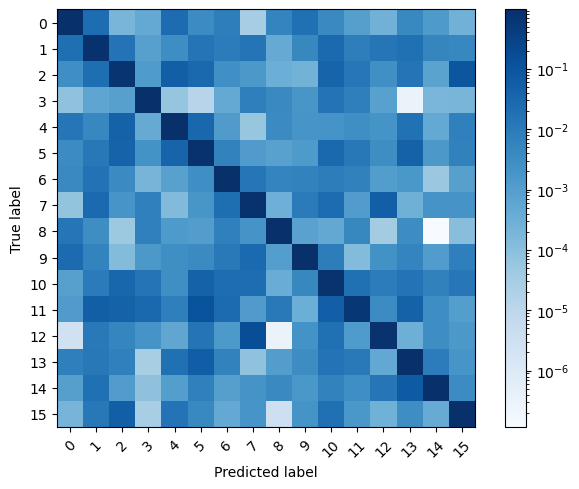

In [35]:
import matplotlib.pyplot as plt
import matplotlib as mpl
#from sklearn.metrics import confusion_matrix
import numpy as np
import itertools

# Sample data
y_true = [2, 0, 2, 2, 0, 1]
y_pred = [0, 0, 2, 2, 0, 2]

# Generating the confusion matrix
#cm = confusion_matrix(y_true, y_pred)

# Plotting
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues, norm=mpl.colors.LogNorm());
plt.colorbar();
tick_marks = np.arange(16);
plt.xticks(tick_marks, ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15'], rotation=45);
plt.yticks(tick_marks, ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15']);

plt.tight_layout();
plt.ylabel('True label');
plt.xlabel('Predicted label');
plt.savefig('/home/lucy.thomas/projects/cog/cogwheel-machine/classifier/small_test/training_confusion_matrix.png');
plt.show();